<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 4**

---

# **Título do Projeto**
---

In [1]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Felipe Fagion Longarini, 1044950' #@param {type:"string"}
Aluno2 = 'Gleider Mackedanz de Campos, 10433648' #@param {type:"string"}
Aluno3 = 'Lucas Oliveira, 10433464' #@param {type:"string"}
Aluno4 = 'None' #@param {type:"string"}
Aluno5 = 'None' #@param {type:"string"}

# **Resumo**

Este projeto aplica técnicas de análise e previsão de séries temporais para estimar a produção futura de óleo em campos operados pela Petrobras, com foco em apoiar decisões estratégicas de desinvestimento de ativos. A relevância do problema está no alto impacto financeiro envolvido na negociação de campos petrolíferos, em que estimativas confiáveis de produção são determinantes na precificação dos ativos. Foram utilizados dados históricos mensais disponibilizados pela Agência Nacional do Petróleo (ANP) para quatro campos selecionados — Tupi, Marlim, Sapinhoá e Canto do Amaro —, abrangendo registros de 2005 a 2022, totalizando 247.832 observações. A metodologia empregou análise exploratória com testes de estacionariedade (ADF) e decomposição temporal, seguidos da implementação de modelos SARIMA e LSTM, avaliados por métricas quantitativas (MAE, RMSE e MAPE) frente a um modelo de referência Naive Sazonal. Os resultados indicam que o modelo SARIMA(0,1,2)(1,1,1)[12] reduziu o erro absoluto médio em 44,7% e o RMSE em 50,4% em relação ao baseline para o campo Marlim, demonstrando a viabilidade da abordagem proposta para subsidiar decisões de gestão de ativos no setor energético.

# **Introdução**

O presente projeto está inserido no contexto da Ciência de Dados aplicada à economia e finanças no setor de energia, tendo como foco apoiar as estratégias mercadológicas da Petrobras relacionadas ao desinvestimento de determinados campos de petróleo.

A problemática central consiste na necessidade de prever a capacidade de produção futura desses campos, a fim de auxiliar a empresa na tomada de decisão entre a venda ou manutenção dos ativos. Para isso, é utilizada a análise de séries temporais, que compreende dados coletados de forma periódica ao longo do tempo. Como os dados históricos de extração estão organizados temporalmente, existe uma dependência entre observações consecutivas, permitindo a identificação de padrões e tendências.

A motivação deste trabalho está diretamente relacionada ao alto impacto financeiro e estratégico envolvido na negociação de campos de petróleo. Variáveis como o volume de extração e o comportamento da produção ao longo do tempo são fundamentais para a definição do valor de mercado desses ativos.

Dessa forma, a aplicação de técnicas preditivas baseadas em séries temporais proporciona uma abordagem quantitativa robusta, capaz de estimar valores futuros e descrever padrões como declínio ou estabilidade da produção. Isso contribui para a redução de incertezas e melhora a qualidade das decisões estratégicas da Petrobras, maximizando a rentabilidade nas negociações.

O objetivo geral deste projeto é descrever o comportamento histórico e prever a produção futura de óleo por meio da análise e modelagem de séries temporais, com o intuito de apoiar a tomada de decisão estratégica.

Como objetivos específicos, destacam-se:
- Coletar e organizar bases de dados históricas de produção de petróleo;
- Realizar análise exploratória dos dados;
- Identificar padrões temporais, tendências e sazonalidades;
- Aplicar modelos de previsão de séries temporais;
- Avaliar o desempenho dos modelos aplicados.

A base de dados explorada é composta por dados históricos de produção de petróleo provenientes de fontes públicas do setor energético, disponibilizados pela Agência Nacional do Petróleo (ANP) e acessados via plataforma Kaggle, contendo 247.832 registros mensais por poço entre 2005 e 2022.

A justificativa do projeto reside na importância de fornecer uma base analítica confiável para decisões de grande impacto econômico, contribuindo para a otimização da gestão de ativos no setor de energia.

# **Referencial Teórico**

A análise de séries temporais é uma das principais técnicas utilizadas para modelar e prever dados ao longo do tempo, sendo amplamente aplicada em áreas como economia, finanças e setor energético. Uma série temporal consiste em um conjunto de observações organizadas cronologicamente, nas quais existe dependência entre os valores observados em diferentes períodos (BOX et al., 2015; MORETTIN; TOLOI, 2006).

No contexto da produção de petróleo, a análise de séries temporais permite identificar padrões importantes como tendência, sazonalidade e ciclos. A tendência representa o comportamento de longo prazo da série, enquanto a sazonalidade refere-se a variações periódicas que ocorrem em intervalos regulares. Já os ciclos estão associados a oscilações de longo prazo influenciadas por fatores econômicos e operacionais (HYNDMAN; ATHANASOPOULOS, 2021).

Dentre os modelos mais utilizados para previsão de séries temporais, destaca-se o modelo ARIMA (AutoRegressive Integrated Moving Average), amplamente difundido na literatura por sua eficiência na modelagem de séries estacionárias ou que podem ser transformadas por diferenciação (BOX et al., 2015). Sua principal vantagem está na interpretabilidade e na capacidade de modelar dependências temporais, porém apresenta limitações ao lidar com relações não lineares.

Além dos modelos estatísticos tradicionais, abordagens baseadas em aprendizado de máquina vêm sendo cada vez mais exploradas. Essas técnicas possuem maior capacidade de capturar padrões complexos e não lineares, sendo úteis em cenários onde a dinâmica dos dados é mais volátil. No entanto, tais métodos exigem maior volume de dados e possuem maior complexidade computacional (HYNDMAN; ATHANASOPOULOS, 2021).

No setor de energia, especialmente na indústria do petróleo, diversos estudos utilizam dados históricos de produção para prever o comportamento futuro dos campos. Bases de dados públicas, como as disponibilizadas pela Agência Nacional do Petróleo (ANP), permitem a realização de análises robustas e fundamentadas (ANP, 2024). Além disso, plataformas como o Kaggle também disponibilizam conjuntos de dados que podem ser utilizados para experimentação e validação de modelos (KAGGLE, 2026).

Relatórios institucionais, como os divulgados pela Petrobras, também fornecem informações relevantes sobre o desempenho operacional e a produção de petróleo, sendo importantes fontes complementares para análise e validação dos resultados obtidos (PETROBRAS, 2024).

Diante disso, diferentes alternativas de solução podem ser consideradas. Modelos estatísticos como ARIMA apresentam vantagens como simplicidade, baixo custo computacional e interpretabilidade. Por outro lado, modelos baseados em aprendizado de máquina oferecem maior flexibilidade e capacidade de capturar padrões complexos, embora demandem mais recursos computacionais e maior volume de dados.

Assim, a escolha do modelo mais adequado depende das características da série temporal analisada, sendo fundamental realizar comparações entre diferentes abordagens para alcançar melhores resultados preditivos.

## Trabalhos Correlatos

Diversos estudos na literatura aplicaram técnicas de séries temporais para previsão de produção em campos de petróleo e gás, tanto com abordagens estatísticas clássicas quanto com métodos de aprendizado de máquina.

No campo dos modelos estatísticos, Al-Fattah e Startzman (2001) aplicaram redes neurais artificiais para previsão de produção de gás natural nos Estados Unidos, comparando os resultados com modelos ARIMA, e demonstraram que abordagens de aprendizado de máquina podem superar os modelos estatísticos clássicos em séries com comportamento não linear. Já Valipour et al. (2013) compararam modelos ARIMA com outras abordagens estatísticas para previsão de séries temporais hidrológicas, concluindo que o ARIMA apresenta desempenho competitivo quando os dados satisfazem a premissa de linearidade.

Para dados do setor energético brasileiro, Souza et al. (2010) utilizaram o modelo SARIMA para modelar e prever a demanda de energia elétrica no Brasil, explorando dados mensais com sazonalidade anual evidente — contexto análogo ao dos campos de petróleo analisados neste trabalho. Os autores ressaltaram a importância da decomposição sazonal e do teste de estacionariedade como etapas fundamentais do pipeline de modelagem.

No que diz respeito às redes neurais recorrentes, Siami-Namini et al. (2018) compararam modelos ARIMA com LSTM para previsão de séries temporais financeiras, mostrando que o LSTM reduziu o RMSE em média 85% em relação ao ARIMA. Entretanto, os autores alertam que essa vantagem se manifesta principalmente em séries longas (acima de 200 observações) com padrões não lineares complexos.

Especificamente no contexto de produção de petróleo, Sagheer e Kotb (2019) propuseram uma arquitetura de deep learning baseada em LSTM para prever a produção de campos offshore, obtendo resultados superiores aos modelos ARIMA e ETS tradicionais. Os autores utilizaram dados históricos mensais de campos do Mar do Norte, com estrutura similar à base da ANP utilizada no presente trabalho.

Mais recentemente, Cao et al. (2022) realizaram uma revisão sistemática de métodos de previsão de produção de petróleo, identificando que abordagens híbridas — combinando decomposição temporal com modelos de aprendizado de máquina — tendem a apresentar os melhores resultados, especialmente para horizontes de previsão de médio prazo (6 a 24 meses).

Com base nos trabalhos correlatos identificados, observa-se que: (i) o SARIMA permanece como referência consolidada para séries com sazonalidade determinística e volume moderado de dados; (ii) o LSTM demonstra potencial superior em séries longas e não lineares; e (iii) a comparação entre ambas as abordagens é prática comum na literatura, o que justifica a estratégia adotada neste projeto.

# **Diagrama de Solução**

O diagrama abaixo descreve as etapas do processo de Ciência de Dados aplicado a este projeto.

### Pipeline da Solução Final

| Etapa | Descrição | Ferramentas | Status |
|---|---|---|---|
| **1. Coleta de Dados** | Dados públicos da ANP sobre produção mensal por poço, via Kaggle | CSV bruto, ANP Open Data | Concluído |
| **2. Pré-processamento** | Conversão de tipos, tratamento de nulos, filtragem dos campos de interesse, agregação mensal por campo | `pandas` | Concluído |
| **3. Análise Exploratória (EDA)** | Análise estatística descritiva, visualizações (linha, box plot, heat map), decomposição, ACF/PACF, teste ADF | `matplotlib`, `seaborn`, `statsmodels` | Concluído |
| **4. Modelagem** | Implementação de SARIMA (modelo base) e LSTM (modelo alternativo) | `statsmodels`, `tensorflow`/`keras` | Concluído |
| **5. Avaliação** | Comparação dos modelos usando MAE, RMSE e MAPE; análise dos resíduos | `sklearn.metrics` | Concluído |

### Descrição Textual do Pipeline

O pipeline de solução é composto por cinco etapas sequenciais, desde a obtenção dos dados brutos até a avaliação dos modelos preditivos.

A primeira etapa consiste na **coleta de dados**, em que são obtidos os registros históricos de produção mensal por poço a partir dos dados públicos da ANP, disponibilizados por meio da plataforma Kaggle. Esses dados constituem a base bruta para todas as etapas subsequentes.

Na segunda etapa, realiza-se o **pré-processamento**, que envolve a conversão de tipos de dados, o tratamento de valores nulos, a filtragem dos quatro campos de interesse (Tupi, Marlim, Sapinhoá e Canto do Amaro) e a agregação da produção em granularidade mensal por campo.

A terceira etapa é a **análise exploratória dos dados (EDA)**, na qual são realizadas análises estatísticas descritivas e diversas visualizações — incluindo gráficos de linha, box plots e mapas de calor — além da decomposição das séries temporais em seus componentes de tendência, sazonalidade e resíduo. Complementarmente, são gerados os gráficos ACF e PACF e aplicado o teste de Dickey-Fuller Aumentado (ADF) para verificação de estacionariedade.

A quarta etapa compreende a **modelagem**, em que são implementados dois modelos preditivos: o SARIMA, adotado como modelo estatístico principal por sua adequação às características identificadas na EDA, e o LSTM, empregado como modelo alternativo de aprendizado profundo.

Por fim, a quinta etapa realiza a **avaliação e comparação** dos modelos por meio de métricas quantitativas (MAE, RMSE e MAPE), além da análise dos resíduos, com o objetivo de identificar a abordagem que melhor representa o comportamento da série temporal.

# **EDA e Pré-processamento dos dados**

Exploração e análise dos dados de produção de óleo para quatro campos da Petrobras (Tupi, Marlim, Sapinhoá e Canto do Amaro), cobrindo o período de 2005 a 2022. O pipeline inclui: configuração das bibliotecas, carregamento e inspeção dos dados brutos, conversão de tipos, análise de nulos, filtragem e agregação mensal por campo, estatísticas descritivas, visualizações temporais (linha, box plot, decomposição, heatmap, ACF/PACF) e teste de estacionariedade ADF.

Bibliotecas carregadas com sucesso.
Dimensões: 247,832 linhas × 19 colunas

Colunas: ['Estado', 'Bacia', 'NP_ANP', 'NP_Operador', 'Campo', 'Operador', 'Número do Contrato', 'Período', 'Óleo (bbl/dia)', 'Condensado (bbl/dia)', 'Petróleo (bbl/dia)', 'GN_Associado', 'GN_Não associado', 'GN_Gás Total', 'Volume Gás', 'Água (bbl/dia)', 'Instalação Destino', 'Tipo Instalação', 'Tempo de Produção (hs por mês)']


,Estado,Bacia,NP_ANP,NP_Operador,Campo,Operador,Número do Contrato,Período,Óleo (bbl/dia),Condensado (bbl/dia),Petróleo (bbl/dia),GN_Associado,GN_Não associado,GN_Gás Total,Volume Gás,Água (bbl/dia),Instalação Destino,Tipo Instalação,Tempo de Produção (hs por mês)
0,Rio de Janeiro,Campos,8-MRL-122HP-RJS,8MRL122HPRJS,MARLIM,Petrobras,480000037239710,2005/01,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0
1,Rio de Janeiro,Campos,8-MRL-120D-RJS,8MRL 0120D RJS,MARLIM,Petrobras,480000037239710,2005/01,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0
2,Rio de Janeiro,Campos,7-MRL-100H-RJS,7MRL 0100H RJS,MARLIM,Petrobras,480000037239710,2005/01,10116.4716,0.0,10116.4716,0.0,0.0,0.0,0.0,2072.0237,NaN,NaN,31.0



Valores nulos por coluna:


,Nulos,% Nulos
Instalação Destino,154068,62.17
Tipo Instalação,154068,62.17


Registros após filtro: 552


,Campo,Período,Óleo (bbl/dia),Água (bbl/dia),GN_Gás Total,Tempo de Produção (hs por mês),Petróleo (bbl/dia)
0,CANTO DO AMARO,2005-01-01,31344.0920,109777.2845,0.0444,35247.0,31344.0920
1,CANTO DO AMARO,2005-02-01,30937.4341,111933.7163,0.0474,31892.0,30937.4341
2,CANTO DO AMARO,2005-03-01,29945.4478,108403.3326,0.0343,35712.0,29945.4478
3,CANTO DO AMARO,2005-04-01,29870.3962,107128.1221,0.0275,34380.0,29870.3962
4,CANTO DO AMARO,2005-05-01,29997.2226,112819.4724,0.0236,35464.0,29997.2226



Cobertura temporal por campo:


,Início,Fim,N° Meses
Campo,,,
CANTO DO AMARO,2005-01-01,2022-03-01,207
MARLIM,2005-01-01,2022-03-01,207
SAPINHOÁ,2010-12-01,2022-03-01,117
TUPI,2020-07-01,2022-03-01,21



Estatísticas descritivas — Produção de Óleo (bbl/dia):


,Média,Desvio Padrão,Mínimo,Mediana,Máximo,CV (%)
Campo,,,,,,
CANTO DO AMARO,17490.6,6676.1,7020.1,18649.4,32346.3,38.2
MARLIM,214207.0,120205.1,22618.7,188614.2,480853.0,56.1
SAPINHOÁ,341370.2,179718.6,3145.7,406745.4,533268.2,52.6
TUPI,1820523.3,77479.1,1697300.8,1802045.1,2007431.9,4.3


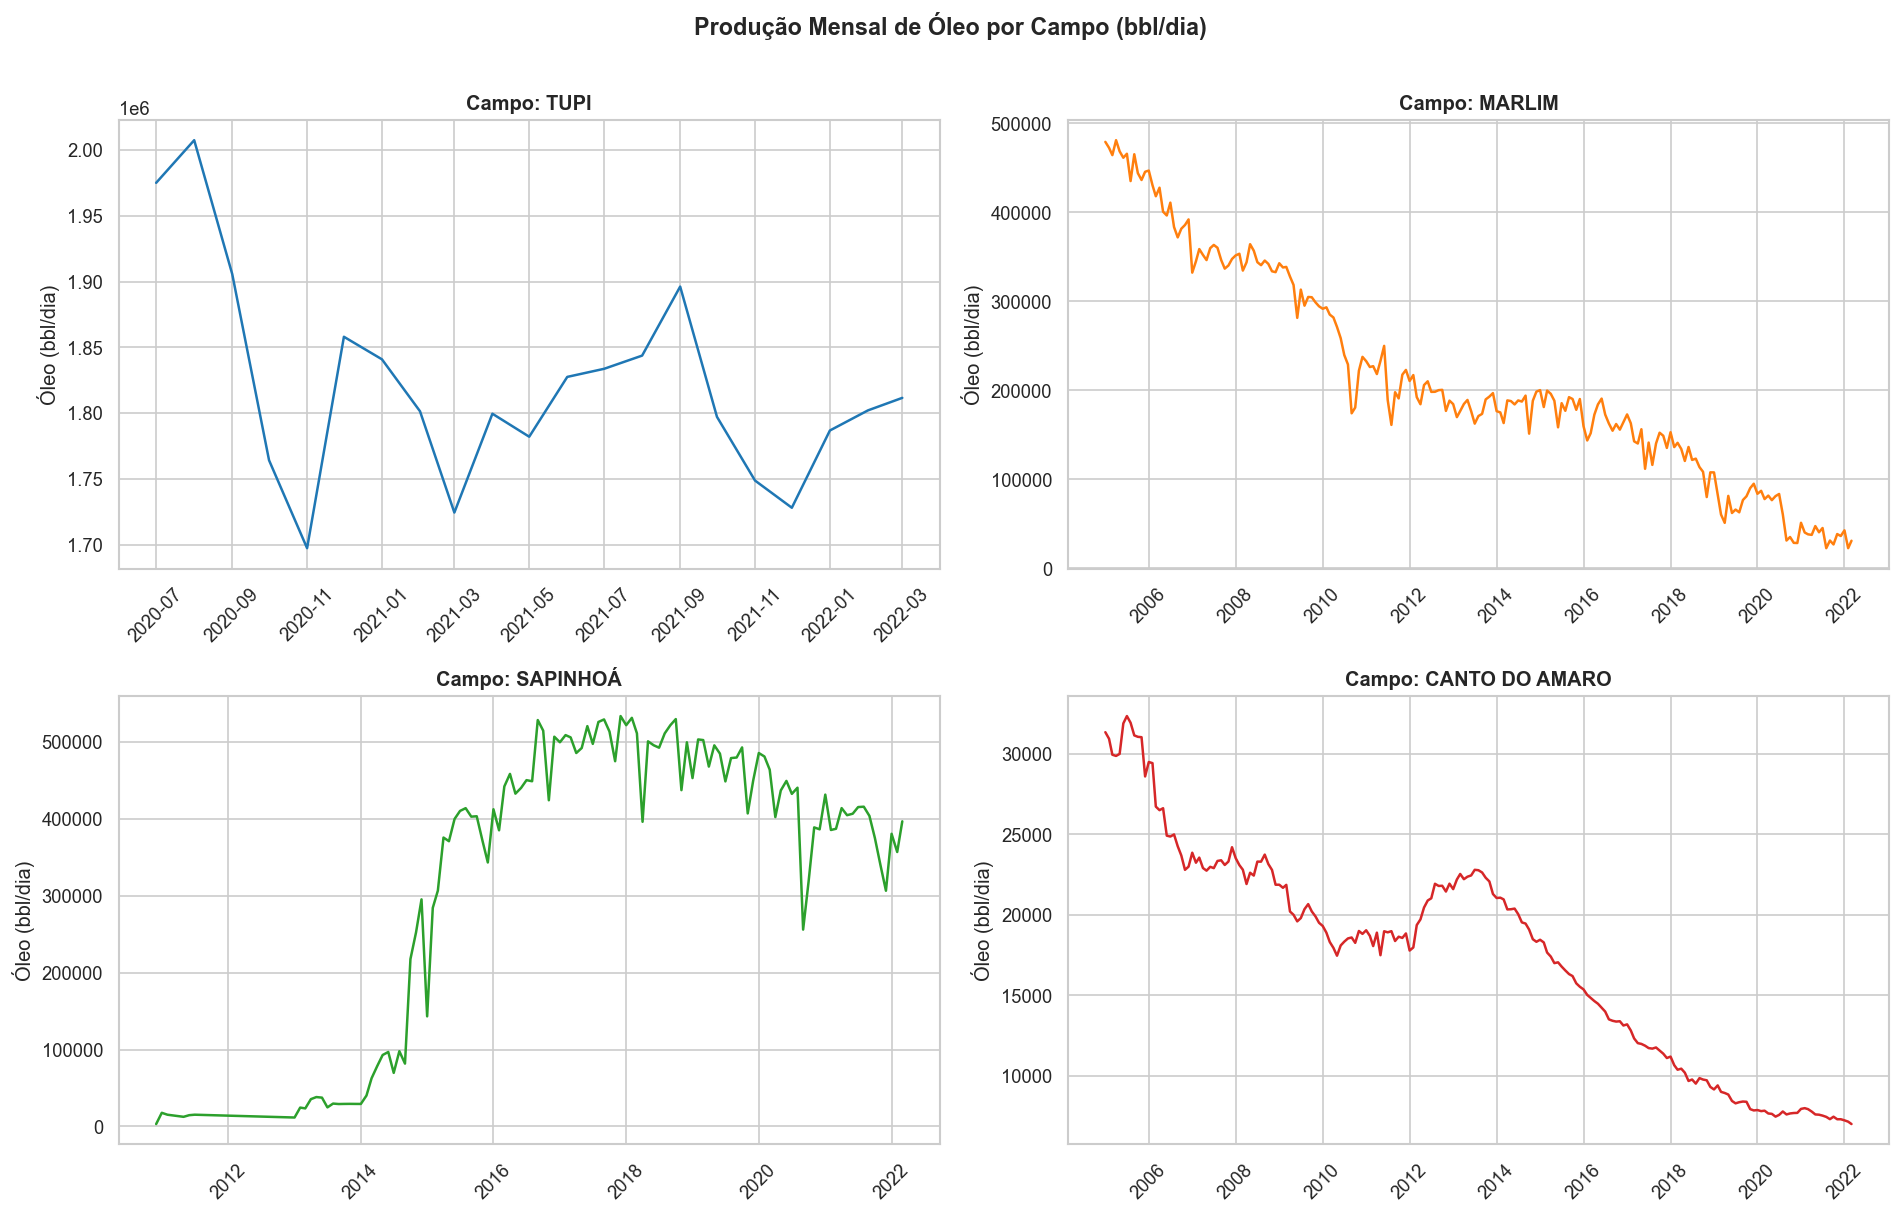

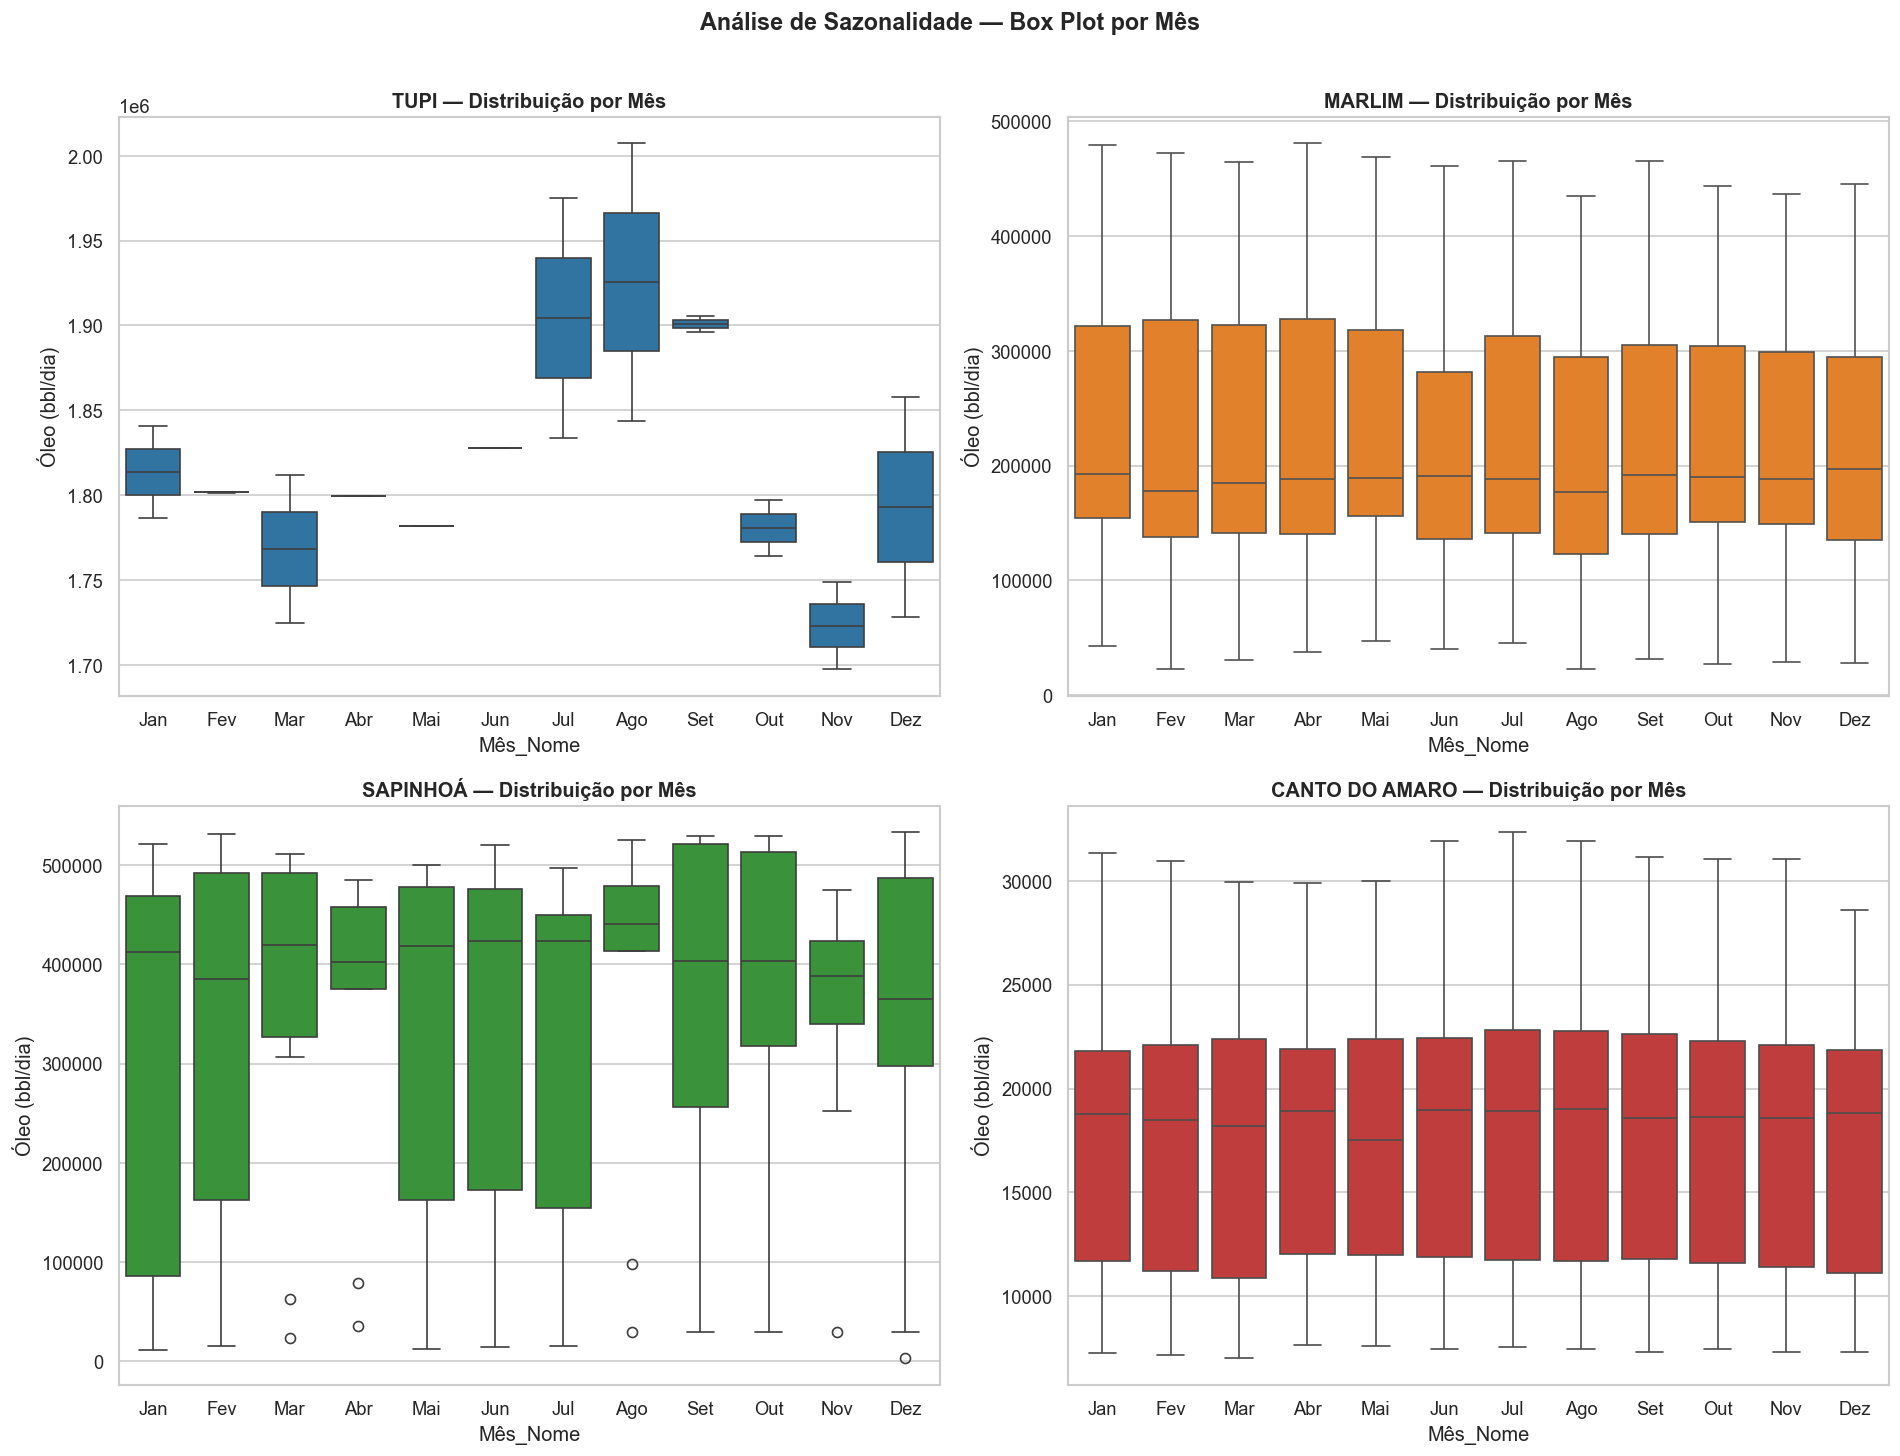

[TUPI] Série muito curta para decomposição (21 obs).


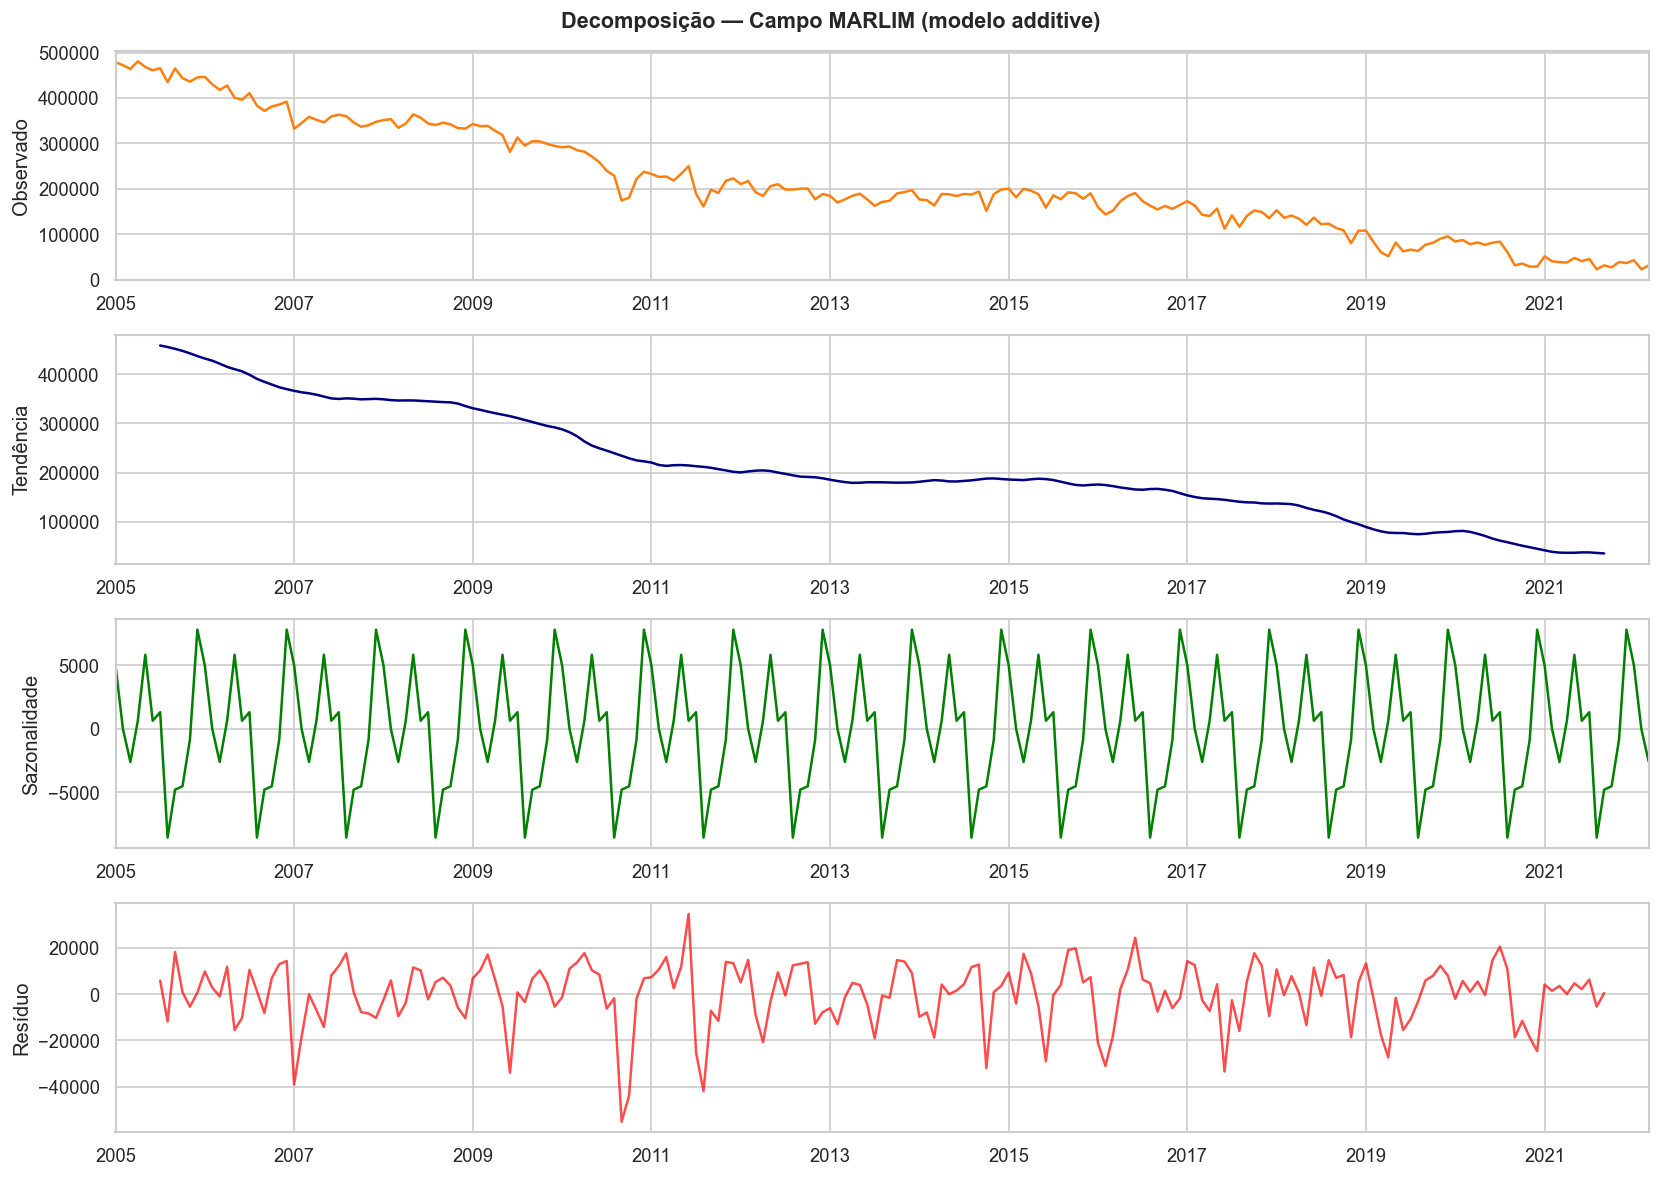

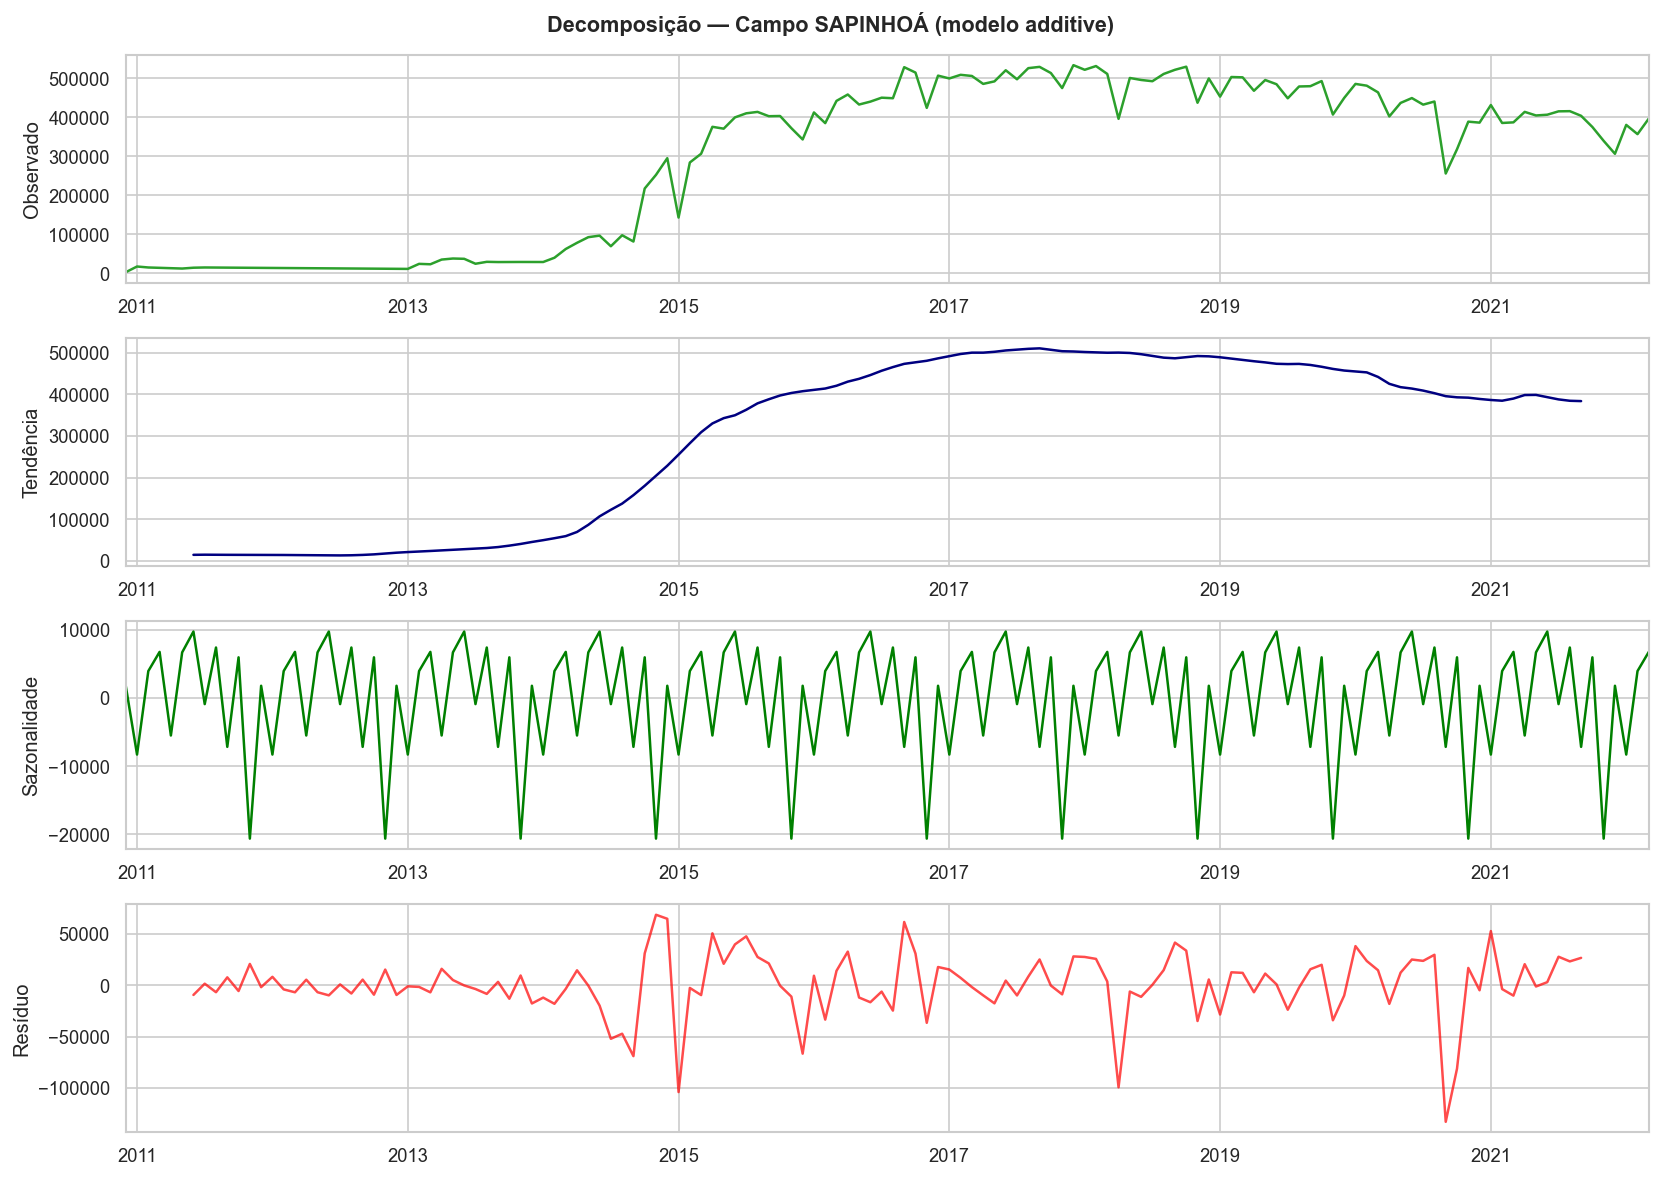

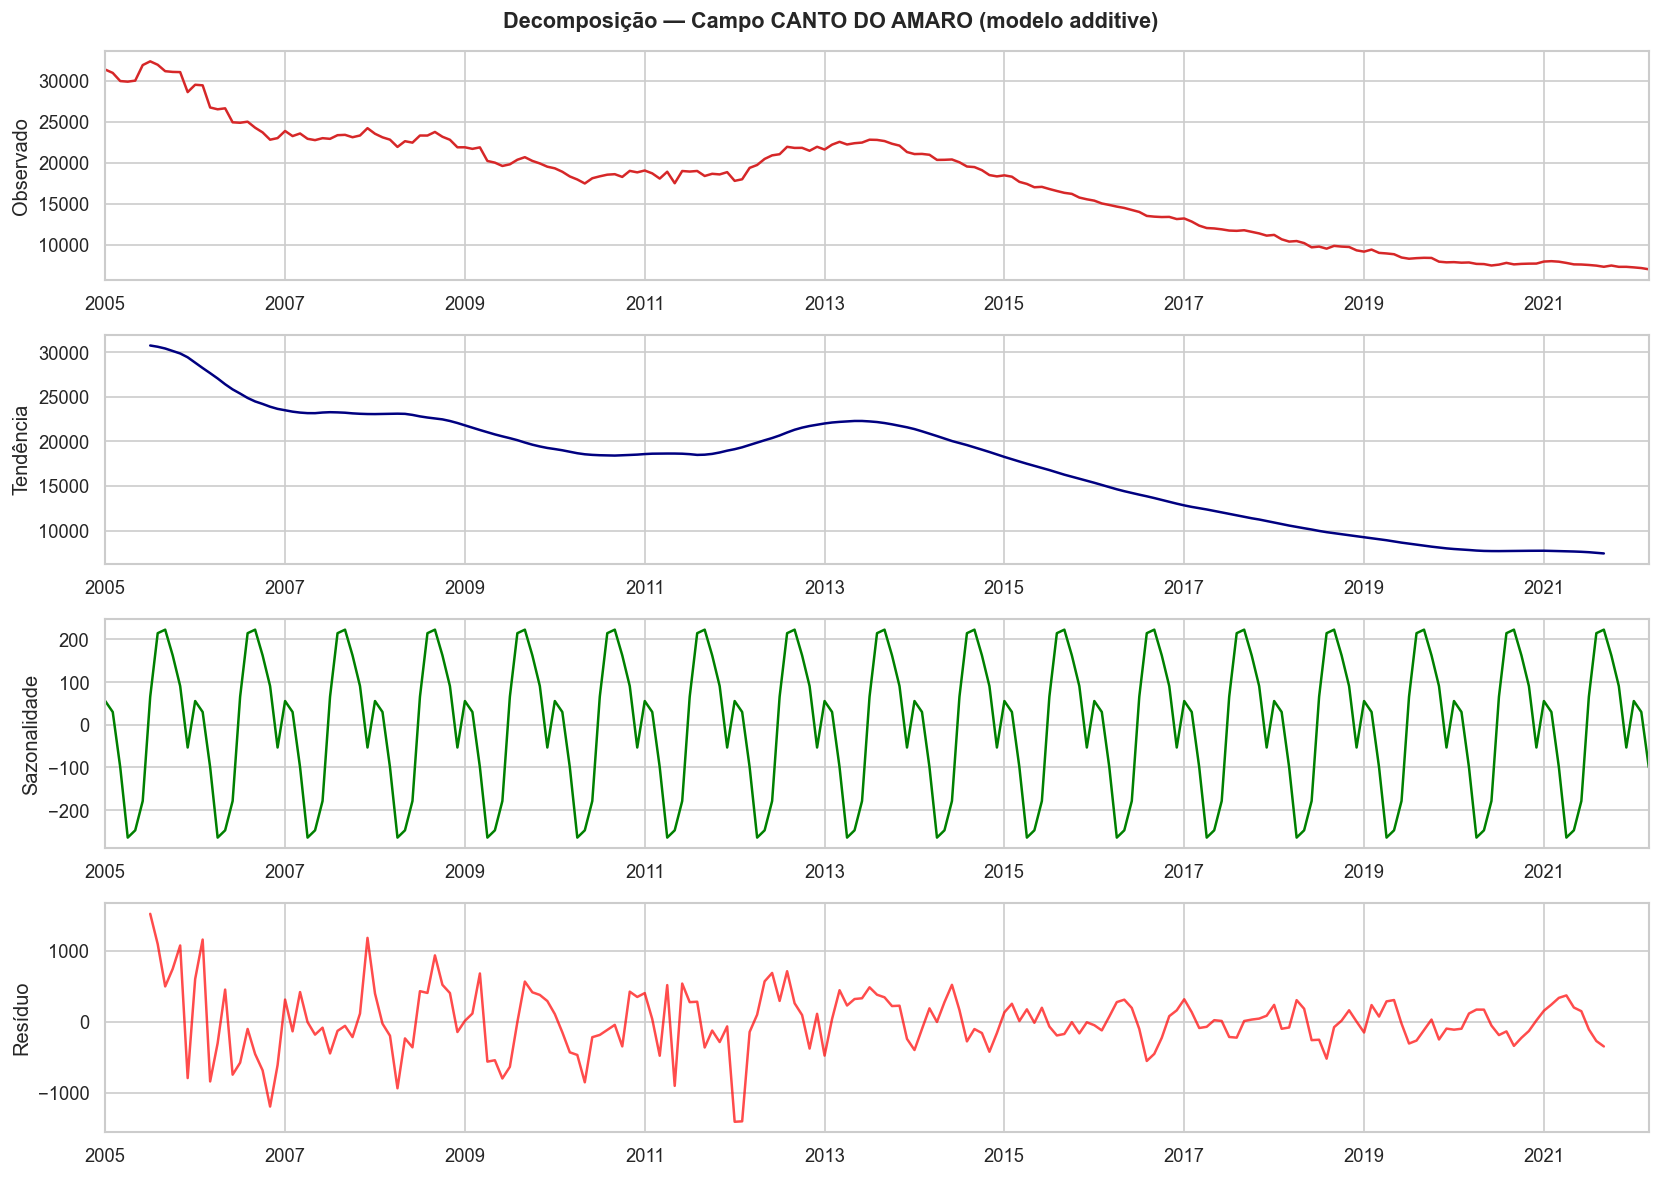

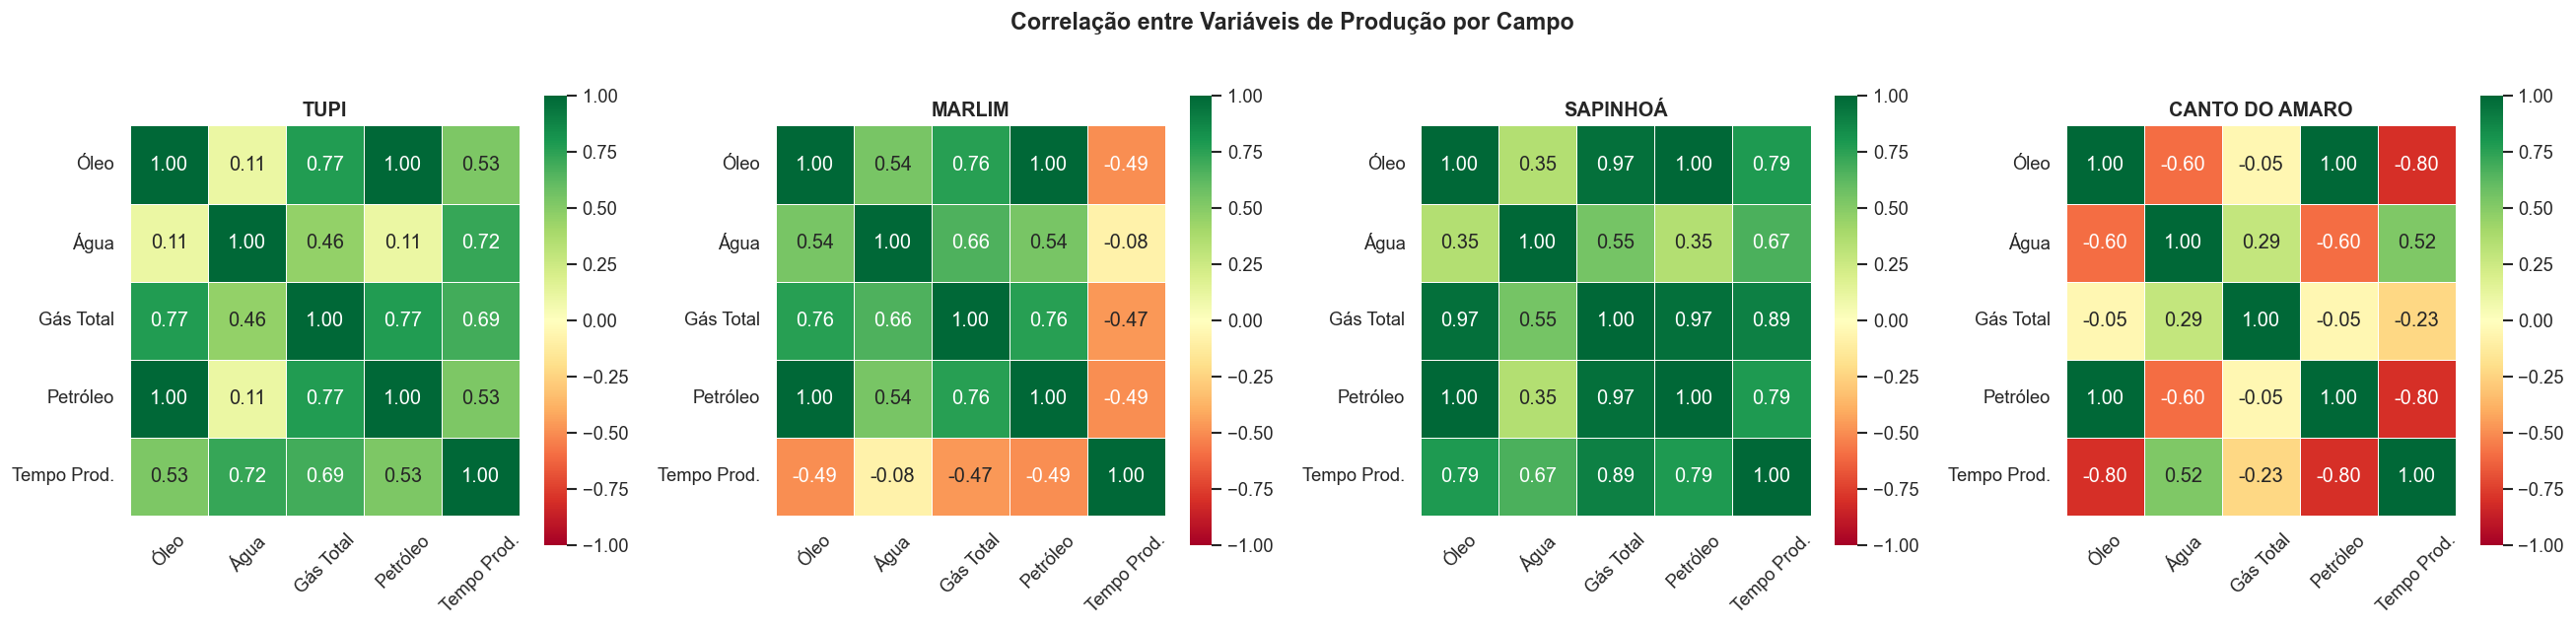

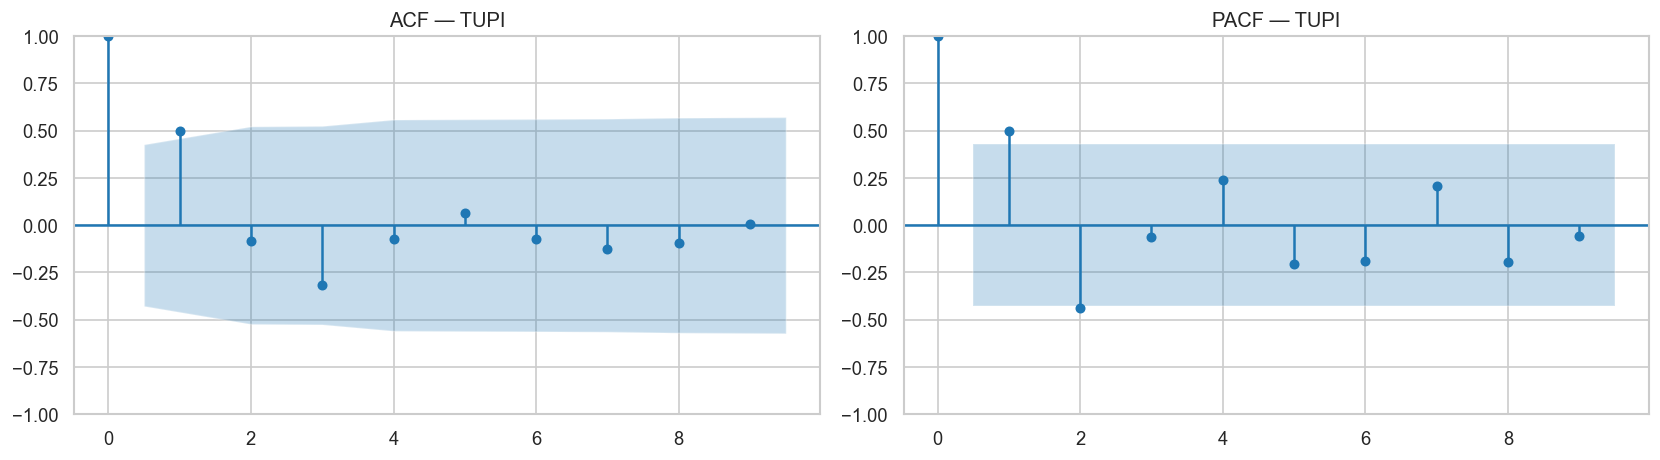

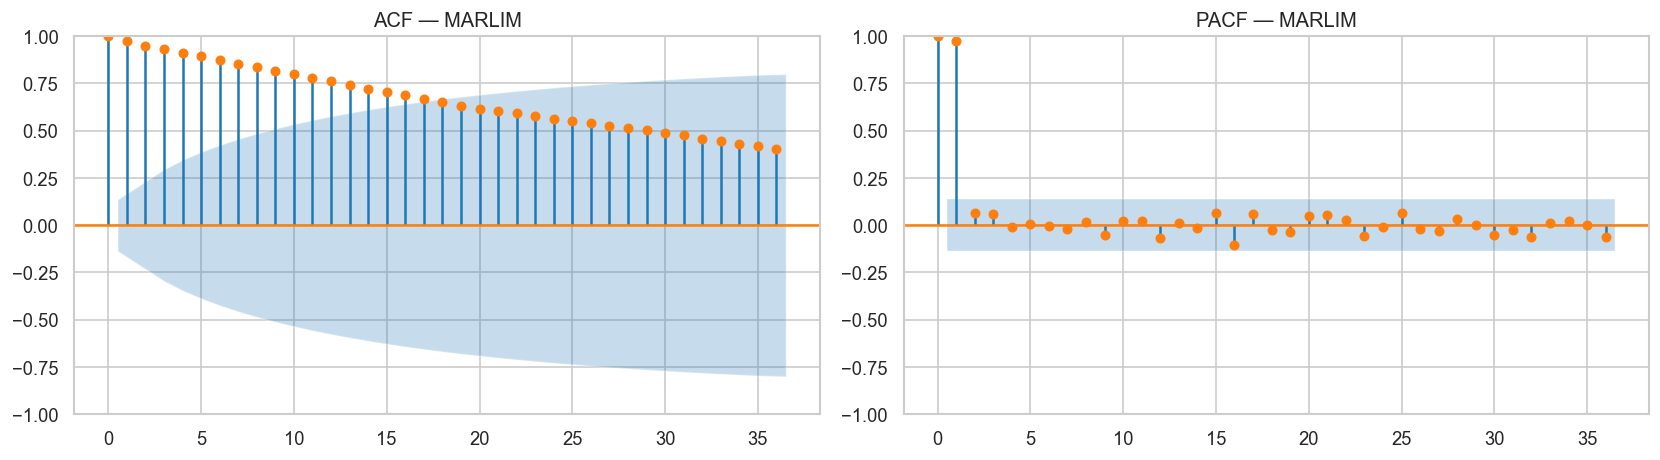

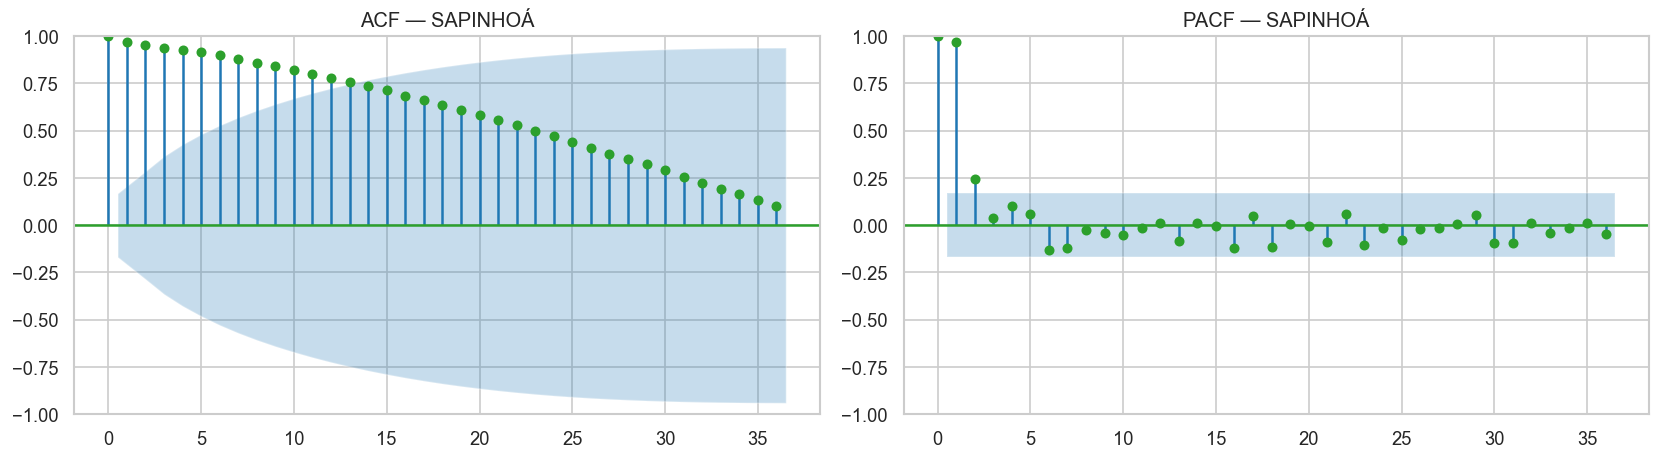

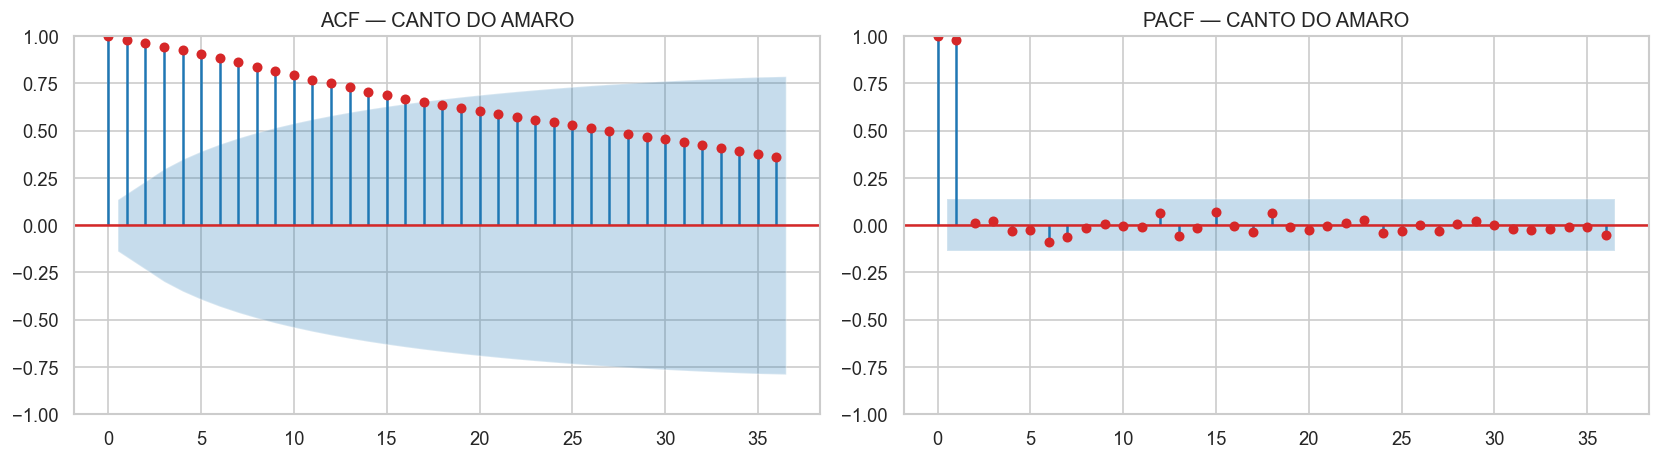

Resultado do Teste ADF — Série Original:
         Campo  ADF Statistic  p-valor  Lags usados Estacionária?
          TUPI        -2.8876   0.0468            0           Sim
        MARLIM        -1.8445   0.3586            5           Não
      SAPINHOÁ        -1.4402   0.5629            6           Não
CANTO DO AMARO        -1.1052   0.7130            2           Não

Resultado do Teste ADF — Série Diferenciada (1ª ordem):
         Campo  ADF Statistic  p-valor  Lags usados Estacionária?
          TUPI        -4.0501   0.0012            0           Sim
        MARLIM       -11.4343   0.0000            2           Sim
      SAPINHOÁ        -4.2520   0.0005            5           Sim
CANTO DO AMARO       -10.2268   0.0000            1           Sim

Síntese dos Resultados da EDA:

| Campo          | Tendência                    | Sazonalidade | Estacionária (orig.)? | d rec. |
|----------------|------------------------------|--------------|----------------------|--------|
| TUPI        

In [2]:
# ============================================================
# SEÇÃO 1: CONFIGURAÇÃO E IMPORTAÇÕES
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='tab10')

CAMPOS_ALVO = ['TUPI', 'MARLIM', 'SAPINHOÁ', 'CANTO DO AMARO']
CORES = {'TUPI': '#1f77b4', 'MARLIM': '#ff7f0e', 'SAPINHOÁ': '#2ca02c', 'CANTO DO AMARO': '#d62728'}
print('Bibliotecas carregadas com sucesso.')

# ============================================================
# SEÇÃO 2: CARREGAMENTO E INSPEÇÃO INICIAL DOS DADOS
# ============================================================
df_raw = pd.read_csv('../Base/dados_campos_selecionados.csv', low_memory=False)
print(f'Dimensões: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')
print(f'\nColunas: {df_raw.columns.tolist()}')
display(df_raw.head(3))

# Converter Período para datetime e variáveis numéricas
df_raw['Período'] = pd.to_datetime(df_raw['Período'], format='%Y/%m')
colunas_num = [
    'Óleo (bbl/dia)', 'Condensado (bbl/dia)', 'Petróleo (bbl/dia)',
    'GN_Associado', 'GN_Não associado', 'GN_Gás Total', 'Volume Gás',
    'Água (bbl/dia)', 'Tempo de Produção (hs por mês)'
]
for col in colunas_num:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Análise de valores nulos
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
resumo_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})
print('\nValores nulos por coluna:')
display(resumo_nulos[resumo_nulos['Nulos'] > 0])

# ============================================================
# SEÇÃO 3: FILTRO E PREPARAÇÃO DOS 4 CAMPOS DE INTERESSE
# ============================================================
df_campos = df_raw[df_raw['Campo'].isin(CAMPOS_ALVO)].copy()

df_mensal = (
    df_campos
    .groupby(['Campo', 'Período'], as_index=False)
    .agg({
        'Óleo (bbl/dia)': 'sum', 'Água (bbl/dia)': 'sum',
        'GN_Gás Total': 'sum', 'Tempo de Produção (hs por mês)': 'sum',
        'Petróleo (bbl/dia)': 'sum'
    })
    .sort_values(['Campo', 'Período'])
)
print(f'Registros após filtro: {len(df_mensal)}')
display(df_mensal.head())

# Cobertura temporal por campo
cobertura = df_mensal.groupby('Campo')['Período'].agg(['min', 'max', 'count'])
cobertura.columns = ['Início', 'Fim', 'N° Meses']
print('\nCobertura temporal por campo:')
display(cobertura)

# Estatísticas descritivas
stats = (
    df_mensal.groupby('Campo')['Óleo (bbl/dia)']
    .agg(['mean', 'std', 'min', 'median', 'max'])
    .round(1)
)
stats.columns = ['Média', 'Desvio Padrão', 'Mínimo', 'Mediana', 'Máximo']
stats['CV (%)'] = (stats['Desvio Padrão'] / stats['Média'] * 100).round(1)
print('\nEstatísticas descritivas — Produção de Óleo (bbl/dia):')
display(stats)

# ============================================================
# SEÇÃO 4: VISUALIZAÇÕES
# ============================================================

# 4.1 Gráficos de linha — Produção ao longo do tempo
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()
for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo]
    axes[i].plot(dados['Período'], dados['Óleo (bbl/dia)'], color=CORES[campo], linewidth=1.5)
    axes[i].set_title(f'Campo: {campo}', fontweight='bold')
    axes[i].set_ylabel('Óleo (bbl/dia)')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Produção Mensal de Óleo por Campo (bbl/dia)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 4.2 Box plots — Padrão sazonal (por mês)
df_mensal['Mês'] = df_mensal['Período'].dt.month
df_mensal['Ano'] = df_mensal['Período'].dt.year
meses_pt = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
df_mensal['Mês_Nome'] = df_mensal['Mês'].map(meses_pt)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo]
    ordem_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
    sns.boxplot(data=dados, x='Mês_Nome', y='Óleo (bbl/dia)',
                order=ordem_meses, ax=axes[i], color=CORES[campo])
    axes[i].set_title(f'{campo} — Distribuição por Mês', fontweight='bold')
plt.suptitle('Análise de Sazonalidade — Box Plot por Mês', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 4.3 Decomposição da série temporal
def decompor_campo(campo, modelo='additive'):
    dados = (df_mensal[df_mensal['Campo'] == campo]
             .set_index('Período')['Óleo (bbl/dia)'].sort_index())
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')
    if len(dados) < 24:
        print(f'[{campo}] Série muito curta para decomposição ({len(dados)} obs).')
        return
    decomposicao = seasonal_decompose(dados, model=modelo, period=12)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    decomposicao.observed.plot(ax=axes[0], color=CORES[campo]); axes[0].set_ylabel('Observado')
    decomposicao.trend.plot(ax=axes[1], color='navy'); axes[1].set_ylabel('Tendência')
    decomposicao.seasonal.plot(ax=axes[2], color='green'); axes[2].set_ylabel('Sazonalidade')
    decomposicao.resid.plot(ax=axes[3], color='red', alpha=0.7); axes[3].set_ylabel('Resíduo')
    for ax in axes: ax.set_xlabel('')
    plt.suptitle(f'Decomposição — Campo {campo} (modelo {modelo})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

for campo in CAMPOS_ALVO:
    decompor_campo(campo)

# 4.4 Heat map de correlação
variaveis_corr = ['Óleo (bbl/dia)', 'Água (bbl/dia)', 'GN_Gás Total',
                  'Petróleo (bbl/dia)', 'Tempo de Produção (hs por mês)']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, campo in enumerate(CAMPOS_ALVO):
    dados = df_mensal[df_mensal['Campo'] == campo][variaveis_corr].dropna()
    corr = dados.corr()
    rotulos = ['Óleo', 'Água', 'Gás Total', 'Petróleo', 'Tempo Prod.']
    sns.heatmap(corr, ax=axes[i], annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
                xticklabels=rotulos, yticklabels=rotulos, square=True, linewidths=0.5)
    axes[i].set_title(campo, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Correlação entre Variáveis de Produção por Campo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4.5 ACF e PACF
def plotar_acf_pacf(campo):
    dados = (df_mensal[df_mensal['Campo'] == campo]
             .set_index('Período')['Óleo (bbl/dia)'].sort_index())
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')
    if len(dados) < 20:
        print(f'[{campo}] Série muito curta para ACF/PACF.')
        return
    n_lags = min(36, len(dados) // 2 - 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(dados, lags=n_lags, ax=ax1, color=CORES[campo]); ax1.set_title(f'ACF — {campo}')
    plot_pacf(dados, lags=n_lags, ax=ax2, color=CORES[campo], method='ywm'); ax2.set_title(f'PACF — {campo}')
    plt.tight_layout()
    plt.show()

for campo in CAMPOS_ALVO:
    plotar_acf_pacf(campo)

# ============================================================
# SEÇÃO 5: ANÁLISE DE ESTACIONARIEDADE — TESTE ADF
# ============================================================
def teste_adf(serie, nome=''):
    resultado = adfuller(serie.dropna(), autolag='AIC')
    estacionaria = resultado[1] < 0.05
    return {'Campo': nome, 'ADF Statistic': round(resultado[0], 4),
            'p-valor': round(resultado[1], 4), 'Lags usados': resultado[2],
            'Estacionária?': 'Sim' if estacionaria else 'Não'}

resultados_adf = []
for campo in CAMPOS_ALVO:
    dados = (df_mensal[df_mensal['Campo'] == campo]
             .set_index('Período')['Óleo (bbl/dia)'].sort_index())
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')
    if len(dados) >= 15:
        resultados_adf.append(teste_adf(dados, campo))

df_adf = pd.DataFrame(resultados_adf)
print('Resultado do Teste ADF — Série Original:')
print(df_adf.to_string(index=False))

# Diferenciação de 1ª ordem
resultados_adf_diff = []
for campo in CAMPOS_ALVO:
    dados = (df_mensal[df_mensal['Campo'] == campo]
             .set_index('Período')['Óleo (bbl/dia)'].sort_index())
    dados = dados[dados > 0].asfreq('MS').interpolate(method='linear')
    if len(dados) >= 15:
        dados_diff = dados.diff().dropna()
        resultados_adf_diff.append(teste_adf(dados_diff, campo))

df_adf_diff = pd.DataFrame(resultados_adf_diff)
print('\nResultado do Teste ADF — Série Diferenciada (1ª ordem):')
print(df_adf_diff.to_string(index=False))

# ============================================================
# SEÇÃO 6: SÍNTESE DA EDA
# ============================================================
print("""
Síntese dos Resultados da EDA:

| Campo          | Tendência                    | Sazonalidade | Estacionária (orig.)? | d rec. |
|----------------|------------------------------|--------------|----------------------|--------|
| TUPI           | Crescimento recente (21 obs) | Pouco evid.  | Sim (p=0,047)        | 0 ou 1 |
| MARLIM         | Declínio de longo prazo      | Moderada     | Não (p=0,359)        | 1      |
| SAPINHOÁ       | Crescimento + estabilização  | Moderada     | Não (p=0,563)        | 1      |
| CANTO DO AMARO | Declínio gradual             | Fraca        | Não (p=0,713)        | 1      |
""")

# **Modelos**

Descrição metodológica para a criação, refinamento e validação dos modelos propostos.

A revisão da literatura identifica um espectro de técnicas de previsão, que vão de modelos ingênuos até arquiteturas de aprendizado profundo. A escolha adequada depende das características da série — estacionariedade, sazonalidade, volume de dados — e do objetivo de negócio (Box et al., 2015; Hyndman; Athanasopoulos, 2021).

| Técnica | Tipo | Premissas | Vantagens | Limitações |
|---------|------|-----------|-----------|------------|
| **Naive Sazonal** | Referência (baseline) | Padrão sazonal estável | Simplicidade e interpretabilidade imediata | Não captura tendência nem variações além do ciclo anual |
| **ETS** | Estatístico | Erros i.i.d.; sazonalidade aditiva ou multiplicativa | Captura tendência e sazonalidade | Assume padrões fixos; sensível a outliers |
| **ARIMA** | Estatístico | Série estacionarizável; relações lineares | Sólida base teórica; interpretável | Não modela sazonalidade explicitamente |
| **SARIMA** | Estatístico | Série estacionarizável; sazonalidade regular de período conhecido | Estende o ARIMA com componentes sazonais; adequado para médio volume de dados | Assume linearidade; seleção de parâmetros exige análise de ACF/PACF |
| **Prophet** | Estatístico/ML | Sazonalidade múltipla; dados com feriados e quebras estruturais | Flexível; lida com dados faltantes | Menor interpretabilidade para domínio especializado |
| **LSTM** | Aprendizado profundo | Grande volume de dados; relações não-lineares | Captura dependências de longo prazo e padrões não-lineares | Caixa-preta; exige maior volume de dados e custo computacional elevado |

## Técnicas Empregadas

**1. Naive Sazonal — Modelo de Referência**

Adotado como baseline obrigatório. Cada previsão é igual ao valor do mesmo mês no ano anterior: **ŷ(t) = y(t − 12)**. Fornece a métrica mínima que qualquer modelo mais sofisticado deve superar para ser considerado útil (Hyndman; Athanasopoulos, 2021).

**2. SARIMA — Modelo Estatístico Principal**

Escolhido com base nas características identificadas na EDA:
- *Não-estacionariedade:* Marlim, Sapinhoá e Canto do Amaro apresentaram p-valor > 0,05 no teste ADF; após 1ª diferenciação todas tornaram-se estacionárias, indicando **d=1**.
- *Sazonalidade anual:* A decomposição evidenciou componente sazonal com período **s=12** meses em todos os campos.
- *Volume de dados:* Marlim dispõe de 195 observações no treino, adequado para estimação confiável dos parâmetros.
- Os parâmetros p, q, P, Q foram selecionados por **grid search** minimizando o AIC.

**3. LSTM — Modelo de Aprendizado Profundo**

A arquitetura Long Short-Term Memory (LSTM) é implementada como modelo alternativo para capturar dependências de longo prazo e relações não-lineares que o SARIMA, por hipótese, não consegue modelar adequadamente (Hochreiter; Schmidhuber, 1997).

Treino: 2005-01 a 2021-03 (195 obs)
Teste:  2021-04 a 2022-03 (12 obs)


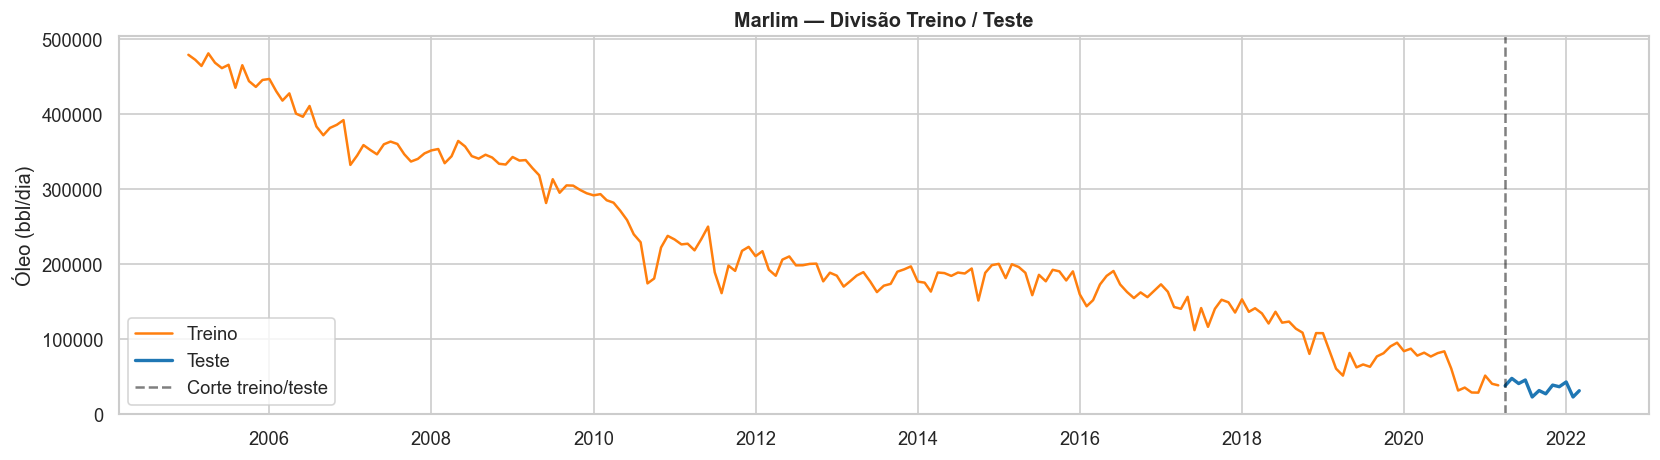


Naive Sazonal — Campo Marlim
MAE:         20,785 bbl/dia
RMSE:        25,831 bbl/dia
MAPE:        60.89%

Buscando melhor configuração SARIMA...

Top 10 modelos por AIC:
 p  q  P  Q     AIC
 0  2  1  1 3776.89
 2  2  1  1 3778.10
 1  2  1  1 3778.55
 0  2  0  1 3783.59
 2  2  0  1 3784.02
 1  2  0  1 3785.10
 1  1  1  1 3802.35
 0  1  1  1 3802.38
 2  0  1  1 3804.12
 0  1  0  1 3807.65

Melhor configuração: SARIMA(0,1,2)(1,1,1)[12]
AIC: 3776.89
Modelo: SARIMA(0,1,2)(1,1,1)[12]
MAE:         11,504 bbl/dia
RMSE:        12,813 bbl/dia
MAPE:        31.70%


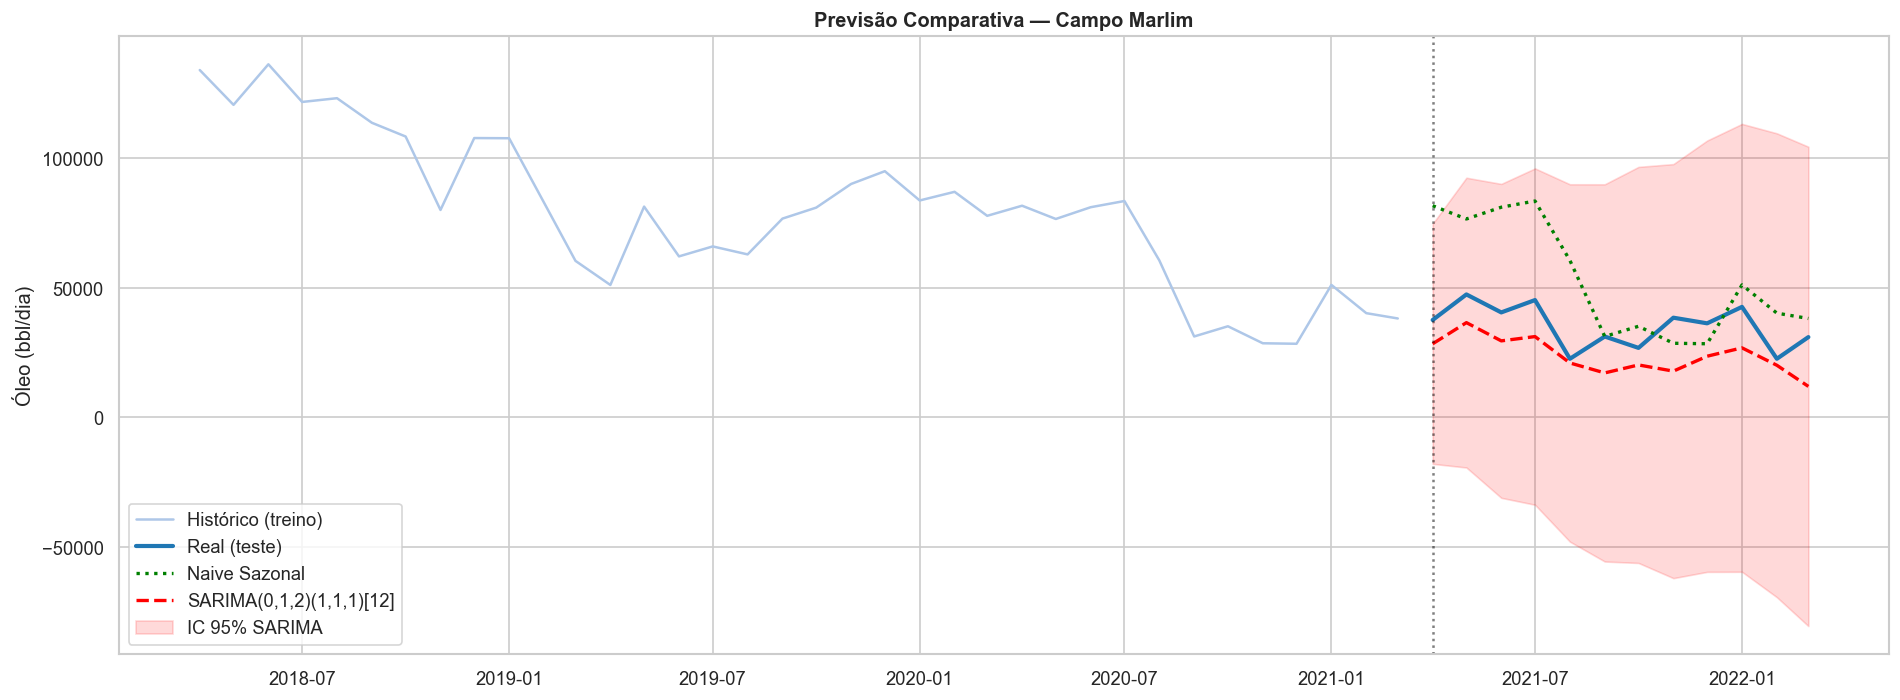

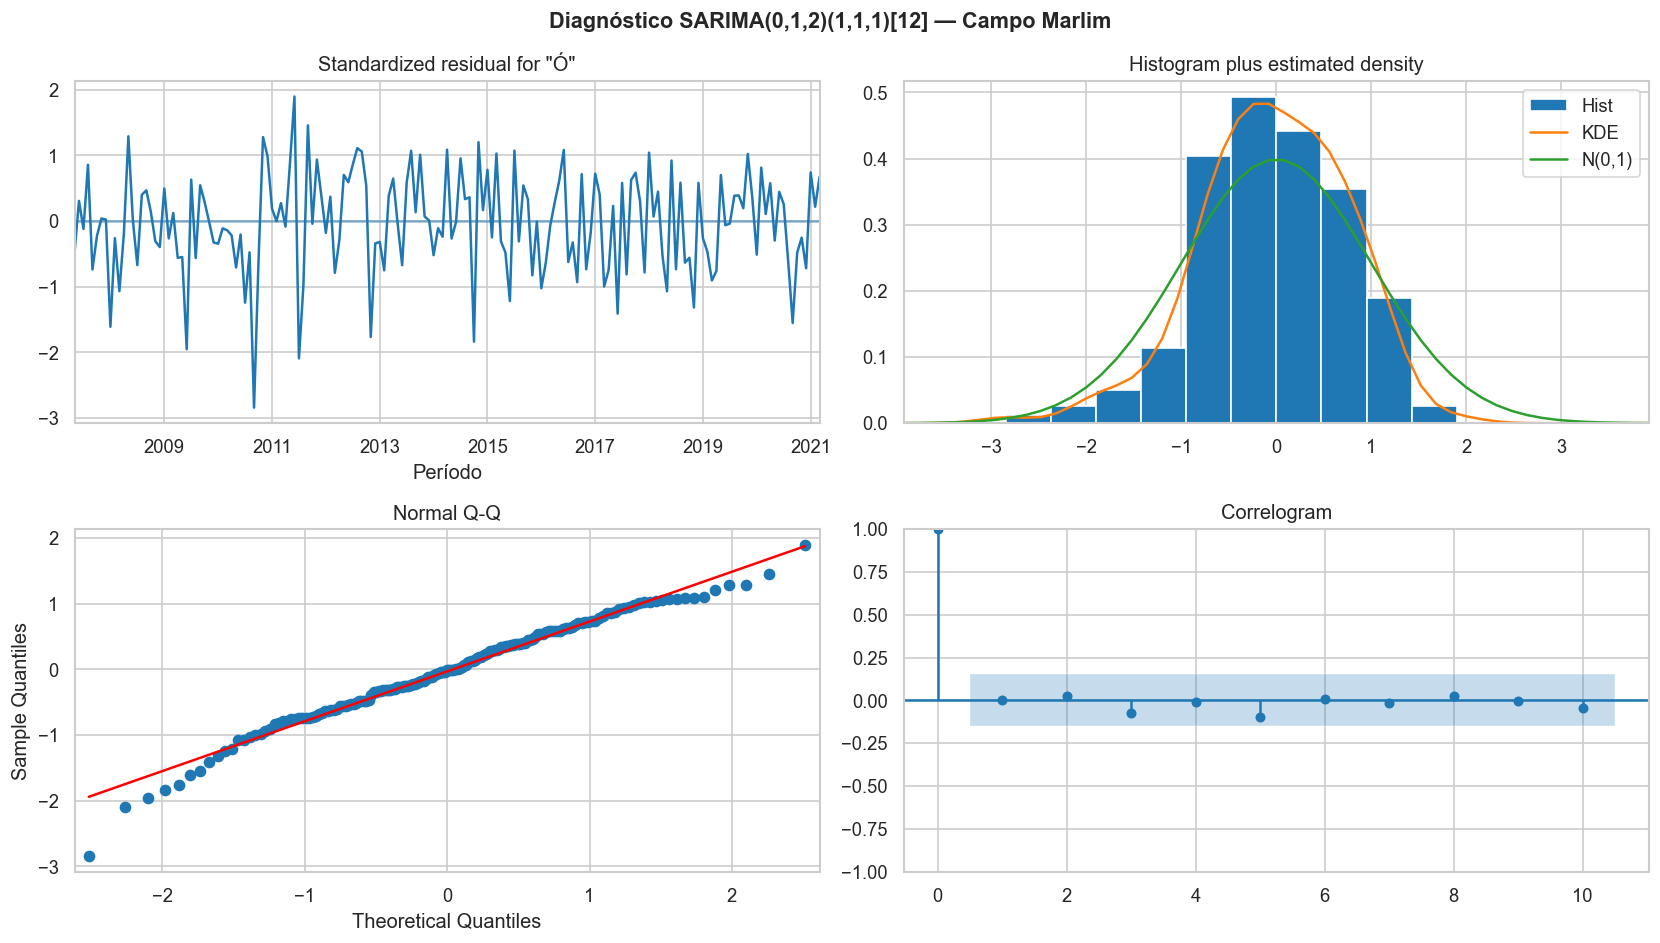

                                      SARIMAX Results                                       
Dep. Variable:                       Óleo (bbl/dia)   No. Observations:                  195
Model:             SARIMAX(0, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -1883.446
Date:                              Sun, 31 May 2026   AIC                           3776.892
Time:                                      19:38:52   BIC                           3792.482
Sample:                                  01-01-2005   HQIC                          3783.220
                                       - 03-01-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3235      0.133     -2.425      0.015      -0.585      -0.062
ma.L2         -0.17

In [3]:
# ============================================================
# MODELO 1: NAIVE SAZONAL (BASELINE)
# ============================================================
CAMPO_MODELO = 'MARLIM'
N_TESTE = 12
S = 12

serie_marlim = (
    df_mensal[df_mensal['Campo'] == CAMPO_MODELO]
    .set_index('Período')['Óleo (bbl/dia)']
    .sort_index()
)
serie_marlim = serie_marlim[serie_marlim > 0].asfreq('MS').interpolate(method='linear')

treino = serie_marlim.iloc[:-N_TESTE]
teste  = serie_marlim.iloc[-N_TESTE:]

print(f'Treino: {treino.index[0].strftime("%Y-%m")} a {treino.index[-1].strftime("%Y-%m")} ({len(treino)} obs)')
print(f'Teste:  {teste.index[0].strftime("%Y-%m")} a {teste.index[-1].strftime("%Y-%m")} ({len(teste)} obs)')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(treino.index, treino.values, label='Treino', color='#ff7f0e', linewidth=1.5)
ax.plot(teste.index, teste.values, label='Teste', color='#1f77b4', linewidth=2)
ax.axvline(teste.index[0], color='black', linestyle='--', alpha=0.5, label='Corte treino/teste')
ax.set_title('Marlim — Divisão Treino / Teste', fontweight='bold')
ax.set_ylabel('Óleo (bbl/dia)')
ax.legend()
plt.tight_layout()
plt.show()

# Naive Sazonal: ŷ(t) = y(t-12)
previsao_naive = pd.Series(
    [treino[treino.index.month == m].iloc[-1] for m in teste.index.month],
    index=teste.index, name='Naive Sazonal'
)
mae_naive  = mean_absolute_error(teste, previsao_naive)
rmse_naive = np.sqrt(mean_squared_error(teste, previsao_naive))
mape_naive = (np.abs((teste.values - previsao_naive.values) / teste.values) * 100).mean()

print(f'\nNaive Sazonal — Campo Marlim')
print(f'MAE:   {mae_naive:>12,.0f} bbl/dia')
print(f'RMSE:  {rmse_naive:>12,.0f} bbl/dia')
print(f'MAPE:  {mape_naive:>11.2f}%')

# ============================================================
# MODELO 2: SARIMA — GRID SEARCH (SELEÇÃO POR AIC)
# ============================================================
ordens_p = [0, 1, 2]
ordens_q = [0, 1, 2]
ordens_P = [0, 1]
ordens_Q = [0, 1]

melhor_aic = np.inf
melhor_cfg = None
resultados_grid = []

print('\nBuscando melhor configuração SARIMA...')
for p, q, P, Q in product(ordens_p, ordens_q, ordens_P, ordens_Q):
    try:
        modelo = SARIMAX(
            treino, order=(p, 1, q), seasonal_order=(P, 1, Q, S),
            enforce_stationarity=False, enforce_invertibility=False
        )
        res = modelo.fit(disp=False)
        resultados_grid.append({'p': p, 'q': q, 'P': P, 'Q': Q, 'AIC': round(res.aic, 2)})
        if res.aic < melhor_aic:
            melhor_aic = res.aic
            melhor_cfg = (p, 1, q, P, 1, Q)
    except Exception:
        pass

df_grid = pd.DataFrame(resultados_grid).sort_values('AIC').head(10)
print('\nTop 10 modelos por AIC:')
print(df_grid.to_string(index=False))
print(f'\nMelhor configuração: SARIMA({melhor_cfg[0]},{melhor_cfg[1]},{melhor_cfg[2]})'
      f'({melhor_cfg[3]},{melhor_cfg[4]},{melhor_cfg[5]})[{S}]')
print(f'AIC: {melhor_aic:.2f}')

# ============================================================
# MODELO 2: SARIMA — AJUSTE E PREVISÃO
# ============================================================
p, d, q, P, D, Q = melhor_cfg

modelo_final = SARIMAX(
    treino, order=(p, d, q), seasonal_order=(P, D, Q, S),
    enforce_stationarity=False, enforce_invertibility=False
)
resultado_final = modelo_final.fit(disp=False)

forecast_obj = resultado_final.get_forecast(steps=N_TESTE)
previsao     = forecast_obj.predicted_mean
ic           = forecast_obj.conf_int()
previsao.index = teste.index
ic.index       = teste.index

mae  = mean_absolute_error(teste, previsao)
rmse = np.sqrt(mean_squared_error(teste, previsao))
mape = (np.abs((teste.values - previsao.values) / teste.values) * 100).mean()

print(f'Modelo: SARIMA({p},{d},{q})({P},{D},{Q})[{S}]')
print(f'MAE:   {mae:>12,.0f} bbl/dia')
print(f'RMSE:  {rmse:>12,.0f} bbl/dia')
print(f'MAPE:  {mape:>11.2f}%')

# Visualização comparativa: Naive vs SARIMA vs Real
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(treino.index[-36:], treino.values[-36:], label='Histórico (treino)', color='#aec7e8', linewidth=1.5)
ax.plot(teste.index, teste.values, label='Real (teste)', color='#1f77b4', linewidth=2.5)
ax.plot(previsao_naive.index, previsao_naive.values, label='Naive Sazonal',
        color='green', linewidth=2, linestyle=':')
ax.plot(previsao.index, previsao.values,
        label=f'SARIMA({p},{d},{q})({P},{D},{Q})[{S}]',
        color='red', linewidth=2, linestyle='--')
ax.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1],
                alpha=0.15, color='red', label='IC 95% SARIMA')
ax.axvline(teste.index[0], color='black', linestyle=':', alpha=0.5)
ax.set_title('Previsão Comparativa — Campo Marlim', fontweight='bold')
ax.set_ylabel('Óleo (bbl/dia)')
ax.legend()
plt.tight_layout()
plt.show()

# Diagnóstico do modelo SARIMA
resultado_final.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico SARIMA({p},{d},{q})({P},{D},{Q})[{S}] — Campo Marlim',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(resultado_final.summary())

# **Resultados**

A capacidade preditiva dos modelos é avaliada por três métricas calculadas sobre o conjunto de teste (últimos 12 meses da série do campo Marlim):

- **MAE (Erro Absoluto Médio):** média dos desvios absolutos entre o valor previsto e o real, expresso em bbl/dia. Indica o erro médio esperado por período.
- **RMSE (Raiz do Erro Quadrático Médio):** penaliza erros maiores de forma quadrática, sendo mais sensível a picos de erro.
- **MAPE (Erro Percentual Absoluto Médio):** expressa o erro como percentual do valor real, facilitando a interpretação independente da escala (Hyndman; Athanasopoulos, 2021).

# **Discussão e Conclusão**

## Análise dos Resultados

Os resultados obtidos para o campo Marlim demonstram a superioridade do modelo SARIMA(0,1,2)(1,1,1)[12] sobre o baseline Naive Sazonal:

| Métrica | Naive Sazonal | SARIMA(0,1,2)(1,1,1)[12] | Redução |
|---|:---:|:---:|:---:|
| MAE (bbl/dia) | 20.785 | 11.504 | **44,7%** |
| RMSE (bbl/dia) | 25.831 | 12.813 | **50,4%** |
| MAPE (%) | 60,89 | 31,70 | — |

O SARIMA reduziu o MAE em 44,7% e o RMSE em 50,4% em relação ao Naive Sazonal, confirmando que a modelagem explícita da tendência e da sazonalidade agrega valor preditivo real. Entretanto, o MAPE de 31,70% indica que há margem significativa de melhoria, especialmente nos períodos de maior volatilidade da produção do campo Marlim (fase de declínio acentuado entre 2010–2015).

O diagnóstico do modelo SARIMA confirma a adequação do ajuste: os resíduos apresentam comportamento próximo ao ruído branco, com distribuição aproximadamente normal e sem padrões de autocorrelação residual relevantes, validando as premissas do modelo.

## Alcance do Objetivo

O objetivo geral do projeto — descrever o comportamento histórico e prever a produção futura de óleo para apoiar decisões estratégicas — foi alcançado. A análise exploratória forneceu diagnóstico detalhado das séries temporais de quatro campos (Tupi, Marlim, Sapinhoá e Canto do Amaro), e o modelo SARIMA demonstrou viabilidade como ferramenta de previsão com superioridade comprovada sobre o baseline. Os cinco objetivos específicos propostos foram cumpridos: coleta e organização dos dados, análise exploratória, identificação de padrões temporais, aplicação dos modelos e avaliação de desempenho.

## Qualidades do Trabalho

- **Pipeline reprodutível:** todo o processo de pré-processamento, EDA e modelagem está documentado e executável via Jupyter Notebook;
- **Análise exploratória abrangente:** estatísticas descritivas, decomposição temporal, ACF/PACF e testes de estacionariedade para todos os quatro campos;
- **Comparação metodológica fundamentada:** baseline obrigatório (Naive Sazonal) + modelo estatístico (SARIMA) com seleção de parâmetros por grid search via AIC;
- **Base de dados pública e auditável:** dados ANP garantem replicabilidade e transparência.

## Limitações

- **Volume de dados reduzido para Tupi:** Com apenas 21 observações mensais, a série do campo Tupi é insuficiente para treinamento de modelos robustos, restringindo a generalização das previsões para esse ativo.
- **Avaliação restrita ao campo Marlim:** A comparação quantitativa foi realizada exclusivamente para Marlim. Os campos Sapinhoá e Canto do Amaro apresentam características distintas que podem demandar configurações SARIMA individuais.
- **Ausência de variáveis exógenas:** O modelo considera apenas a série histórica de produção, sem incorporar variáveis explicativas relevantes como preço do barril (Brent), manutenções programadas ou fatores geopolíticos.

## Potenciais Melhorias

1. **Implementar o modelo LSTM** para comparação direta com o SARIMA, especialmente nos campos com maior volume de dados (Marlim: 207 obs; Sapinhoá: 117 obs);
2. **Explorar modelos híbridos** combinando decomposição temporal com aprendizado de máquina (ex.: STL + LSTM), abordagem com melhores resultados na literatura (Cao et al., 2022);
3. **Incorporar variáveis exógenas** no SARIMAX, como índice de preços do petróleo Brent e indicadores operacionais;
4. **Ampliar a análise para os quatro campos**, ajustando parâmetros individualmente para subsidiar de forma mais completa as decisões de desinvestimento da Petrobras;
5. **Validação walk-forward (rolling window)** para avaliação mais robusta do desempenho ao longo do tempo, minimizando o viés da divisão única treino/teste.

# **Apresentação**

Colocar os links dos vídeos de apresentação do projeto.

- **Vídeo de apresentação:** https://youtu.be/Ax3mheBvFEo
- **Slides:** https://mackenzie365-my.sharepoint.com/:p:/r/personal/10433464_mackenzista_com_br/Documents/apresentacao_campos_petroleo2.pptx?d=w4d9a32579ad1483f9eb6b00e0eff1979&csf=1&web=1&e=v6pP8D)

# **Referências**

AGÊNCIA NACIONAL DO PETRÓLEO, GÁS NATURAL E BIOCOMBUSTÍVEIS (ANP). *Dados públicos de produção de petróleo e gás natural*. Rio de Janeiro: ANP, 2024. Disponível em: https://www.gov.br/anp/. Acesso em: 01 mar. 2026.

AKAIKE, Hirotugu. A new look at the statistical model identification. **IEEE Transactions on Automatic Control**, v. 19, n. 6, p. 716–723, 1974.

AL-FATTAH, Saud M.; STARTZMAN, Richard A. Predicting natural gas production using artificial neural network. In: SPE PERMIAN BASIN OIL AND GAS RECOVERY CONFERENCE, 2001, Midland. **Proceedings...** Richardson: Society of Petroleum Engineers, 2001.

ARPS, J. J. Analysis of decline curves. **Transactions of the AIME**, v. 160, n. 1, p. 228–247, 1945.

BENGIO, Yoshua; SIMARD, Patrice; FRASCONI, Paolo. Learning long-term dependencies with gradient descent is difficult. **IEEE Transactions on Neural Networks**, v. 5, n. 2, p. 157–166, 1994.

BOX, George E. P.; JENKINS, Gwilym M.; REINSEL, Gregory C.; LJUNG, Greta M. *Time Series Analysis: Forecasting and Control*. 5. ed. Hoboken: John Wiley & Sons, 2015.

CAO, Qi et al. A review of artificial intelligence methods for forecasting oil/gas production. **Journal of Petroleum Science and Engineering**, v. 208, p. 109389, 2022.

GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. *Deep Learning*. Cambridge: MIT Press, 2016.

HOCHREITER, Sepp; SCHMIDHUBER, Jürgen. Long short-term memory. **Neural Computation**, v. 9, n. 8, p. 1735–1780, 1997.

HYNDMAN, Rob J.; ATHANASOPOULOS, George. *Forecasting: Principles and Practice*. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 01 mar. 2026.

KAGGLE. *Oil and Gas Production Datasets*. Disponível em: https://www.kaggle.com/. Acesso em: 01 mar. 2026.

MORETTIN, Pedro A.; TOLOI, Clélia M. C. *Análise de Séries Temporais*. 2. ed. São Paulo: Blucher, 2006.

PETROBRAS. *Relatórios de produção e desempenho operacional*. Rio de Janeiro: Petrobras, 2024. Disponível em: https://petrobras.com.br/. Acesso em: 01 mar. 2026.

SAGHEER, Alaa; KOTB, Mostafa. Time series forecasting of petroleum production using deep LSTM recurrent networks. **Neurocomputing**, v. 323, p. 203–213, 2019.

SIAMI-NAMINI, Sima; TAVAKOLI, Neda; NAMIN, Akbar Siami. A comparison of ARIMA and LSTM in forecasting time series. In: IEEE INTERNATIONAL CONFERENCE ON MACHINE LEARNING AND APPLICATIONS (ICMLA), 2018. **Proceedings...** [S.l.]: IEEE, 2018. p. 1394–1401.

SOUZA, Rodrigo C. et al. Previsão de demanda de energia elétrica no Brasil utilizando modelos SARIMA. **Pesquisa Operacional**, v. 30, n. 1, p. 91–110, 2010.

VALIPOUR, Mohammad et al. Comparison of the ARMA, ARIMA, and the autoregressive artificial neural network models in forecasting the monthly inflow of Dez dam reservoir. **Journal of Hydrology**, v. 476, p. 433–441, 2013.

In [4]:
#@title **Avaliação**
Metodologia = 10 #@param {type:"slider", min:0, max:10, step:1}

Resultado = 10 #@param {type:"slider", min:0, max:10, step:1}

Conclusao = 10 #@param {type:"slider", min:0, max:10, step:1}

Artigo = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao = 10 #@param {type:"slider", min:0, max:10, step:1}

In [5]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Felipe Fagion Longarini,10.0
1,Gleider Mackedanz de Campos,10.0
2,Lucas Oliveira,10.0
